## Importing all the essentials library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/stud.csv")

## Now after importing the csv we will do the following tasks:

1: Check dataset

2: Check missing values

3: Check duplicate values

4: Check shape of dataset

5: Check desc of datset

6: Explore thr dataset

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

#### We have 1000 rows and 10 columns in the dataset. Let's check the null values in the dataset.

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

##### We have no null values 

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Here we can see in the description that the mean of the all the three score is almost same with the very less difference.


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
print("Columns in the dataset:", df.columns.tolist())

Columns in the dataset: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [10]:
print("We have two types of gender in the dataset: ", df["gender"].unique())
print("We have 5 types of race_ethnicity in the dataset: ", df["race_ethnicity"].unique())
print("We have 6 types of parental_level_of_education in the dataset: ", df["parental_level_of_education"].unique())
print("We have 2 types of lunch in the dataset: ",df["lunch"].unique())
print("We have 2 types of test_preparation_course in the dataset: ",df["test_preparation_course"].unique())

We have two types of gender in the dataset:  ['female' 'male']
We have 5 types of race_ethnicity in the dataset:  ['group B' 'group C' 'group A' 'group D' 'group E']
We have 6 types of parental_level_of_education in the dataset:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
We have 2 types of lunch in the dataset:  ['standard' 'free/reduced']
We have 2 types of test_preparation_course in the dataset:  ['none' 'completed']


In [11]:
numeric_columns = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_columns = [feature for feature in df.columns if df[feature].dtype == "O"]

print("We have {} numerical columns: {}".format(len(numeric_columns), numeric_columns))
print("We have {} categorical columns: {}".format(len(categorical_columns), categorical_columns))

We have 3 numerical columns: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical columns: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]

In [13]:
df["average_score"] = df["total_score"]/3

In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [15]:
reading_full = df[df["reading_score"] == 100]["average_score"].count()
writing_full = df[df["writing_score"] == 100]["average_score"].count()
math_full = df[df["math_score"] == 100]["average_score"].count()

print(f"Number of students with full marks in reading: {reading_full}")
print(f"Number of students with full marks in writing: {writing_full}")
print(f"Number of students with full marks in math: {math_full}")  

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [16]:
reading_less_40 = df[df["reading_score"] <= 40]["average_score"].count()
writing_less_40 = df[df["writing_score"] <= 40]["average_score"].count()
math_less_40 = df[df["math_score"] <= 40]["average_score"].count()

print(f"Number of students with less than or equal to 40 marks in reading: {reading_less_40}")
print(f"Number of students with less than or equal to 40 marks in writing: {writing_less_40}")
print(f"Number of students with less than or equal to 40 marks in math: {math_less_40}")

Number of students with less than or equal to 40 marks in reading: 27
Number of students with less than or equal to 40 marks in writing: 35
Number of students with less than or equal to 40 marks in math: 50


### Insights 

##### Students have performed worst in maths if we compare with the reading score and the writing score
##### And performed relatively good in reading

# Now Visualization

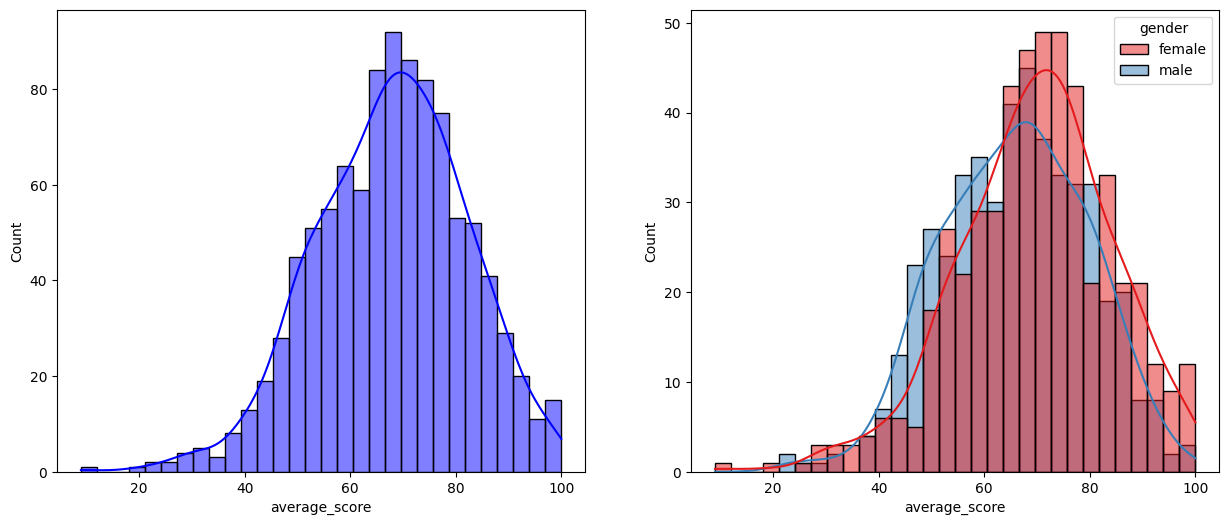

In [17]:
fig , ax = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1,2,1)
sns.histplot(data=df , x="average_score", bins = 30, kde=True, color= "blue")
plt.subplot(1,2,2)
sns.histplot(data=df , x ="average_score", hue="gender", bins = 30, kde=True, palette= "Set1")
plt.show()


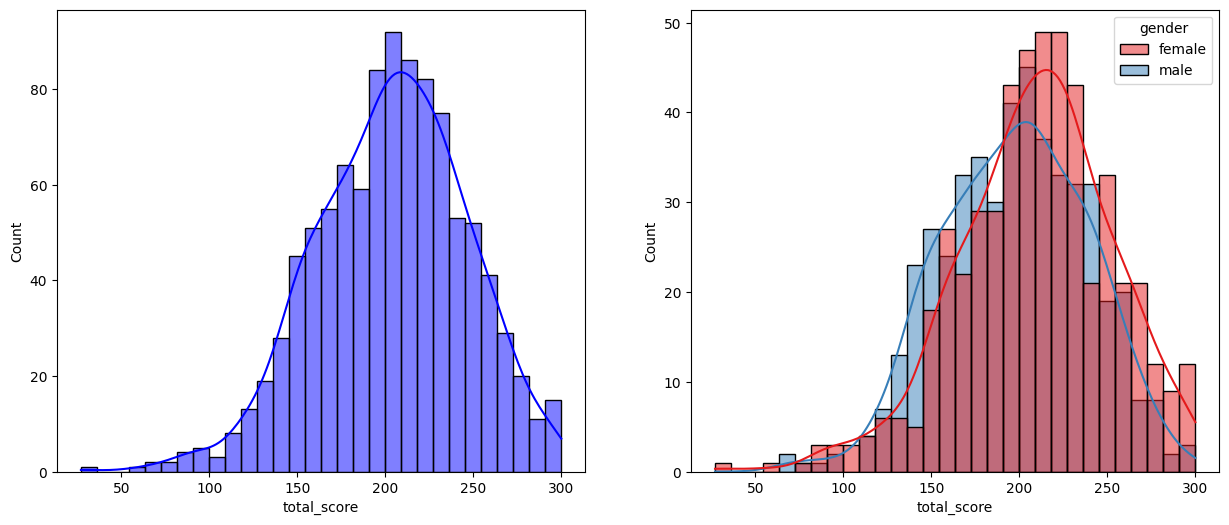

In [18]:
fig , ax = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1,2,1)
sns.histplot(data=df , x="total_score", bins = 30, kde=True, color= "blue")
plt.subplot(1,2,2)
sns.histplot(data=df , x ="total_score", hue="gender", bins = 30, kde=True, palette= "Set1")
plt.show()

## Insight:

### So here we can see that Female tends to score better marks than compare to the Male 

In [19]:
df["test_preparation_course"].unique()

array(['none', 'completed'], dtype=object)

<Axes: xlabel='test_preparation_course'>

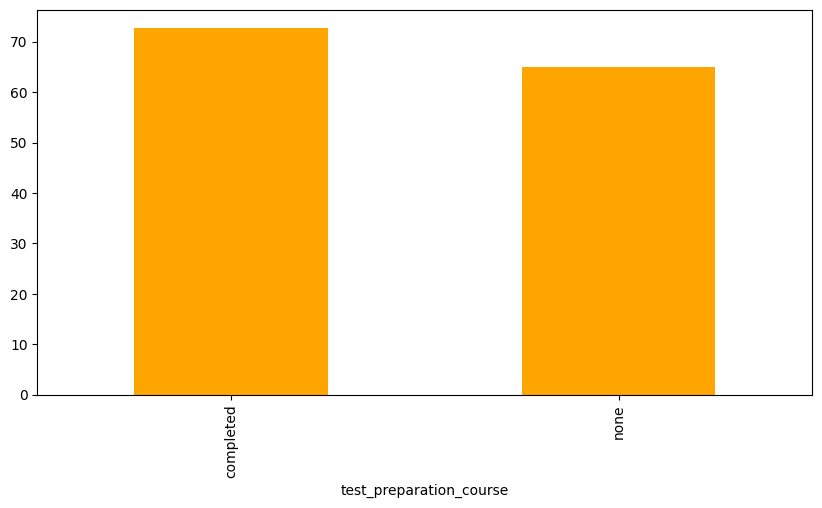

In [20]:
df.groupby("test_preparation_course")["average_score"].mean().plot(kind="bar",figsize=(10,5), color="orange")

<Axes: xlabel='test_preparation_course'>

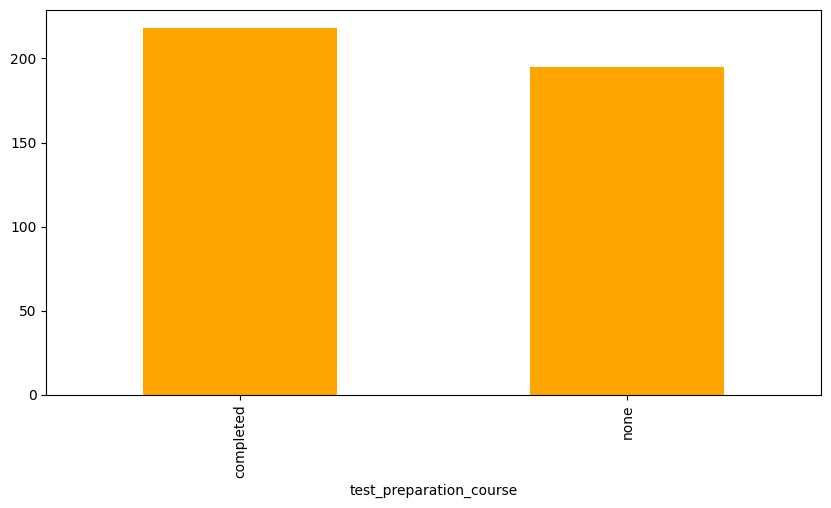

In [21]:
df.groupby("test_preparation_course")["total_score"].mean().plot(kind="bar",figsize=(10,5), color="orange")

## Insight:

#### It has been observed that the student who completed the test preparation course tends to have a high marks than the student who didn't completed

In [22]:
df.head(2)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


<Axes: xlabel='race_ethnicity'>

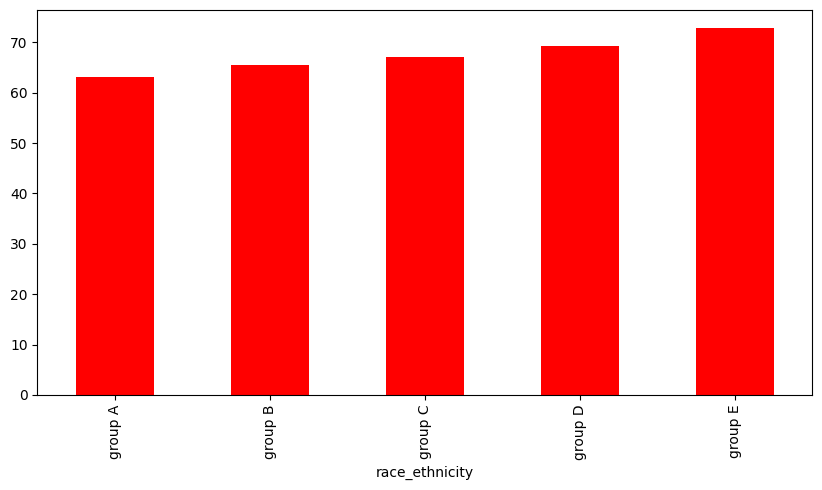

In [24]:
df.groupby("race_ethnicity")["average_score"].mean().plot(kind="bar",figsize=(10,5), color="red")

<Axes: xlabel='race_ethnicity'>

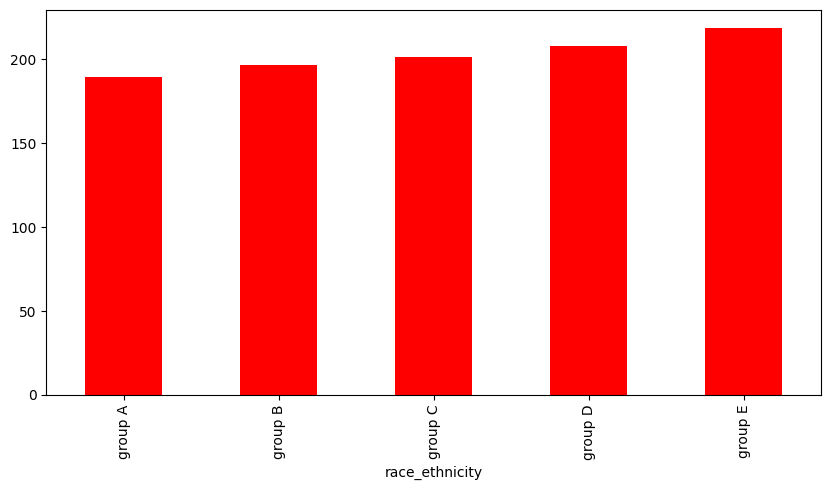

In [26]:
df.groupby("race_ethnicity")["total_score"].mean().plot(kind="bar",figsize=(10,5), color="red")

## Insight

### Here we can see the gradual increase in the marks from Group A to Group E and Group E tends to have the highest marks among all the group

<Axes: xlabel='race_ethnicity'>

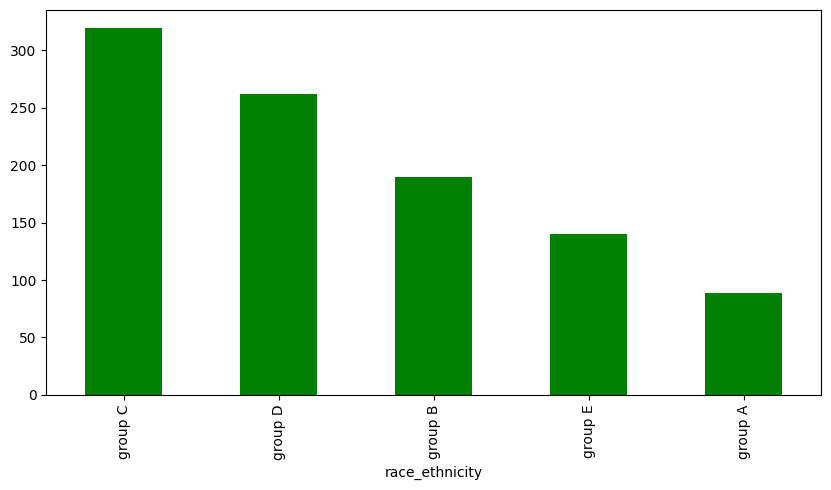

In [31]:
df["race_ethnicity"].value_counts().plot(kind="bar",figsize=(10,5), color="green")

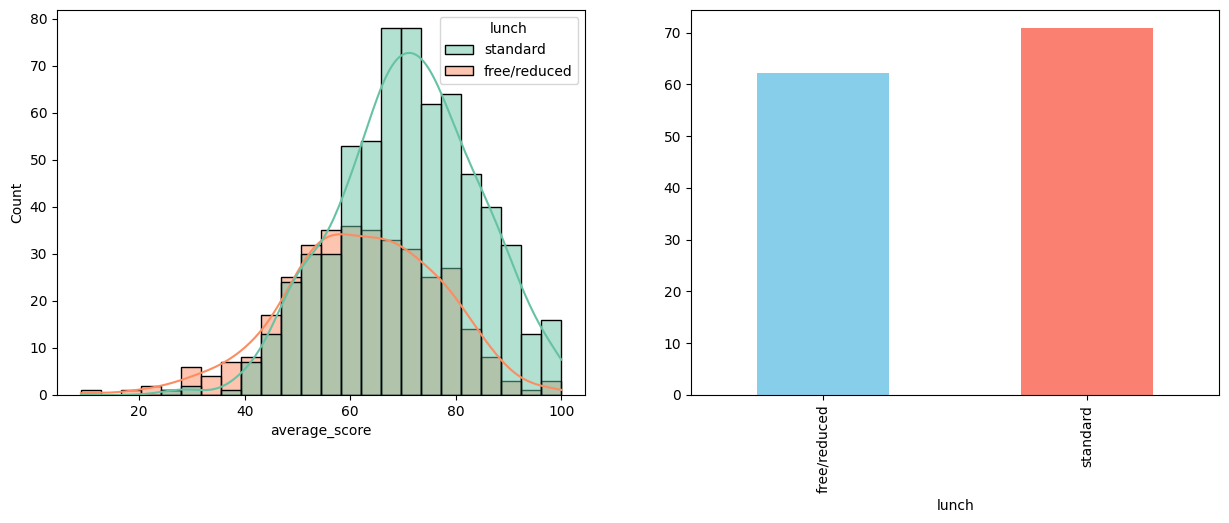

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x="average_score", hue="lunch", kde=True, ax=ax[0], palette="Set2")
df.groupby("lunch")["average_score"].mean().plot(kind="bar", color=["skyblue", "salmon"], ax=ax[1])
plt.show()

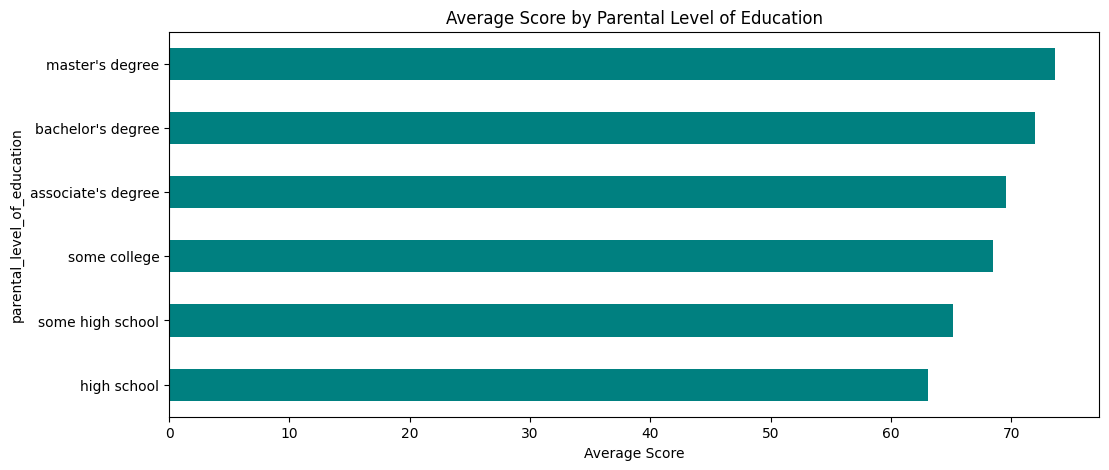

In [33]:
plt.figure(figsize=(12, 5))
df.groupby("parental_level_of_education")["average_score"].mean().sort_values().plot(kind="barh", color="teal")
plt.title("Average Score by Parental Level of Education")
plt.xlabel("Average Score")
plt.show()

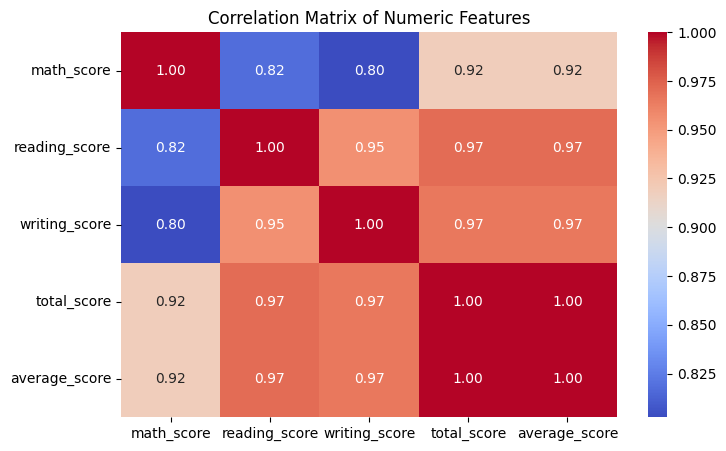

In [34]:
plt.figure(figsize=(8, 5))
numeric_df = df[["math_score", "reading_score", "writing_score", "total_score", "average_score"]]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

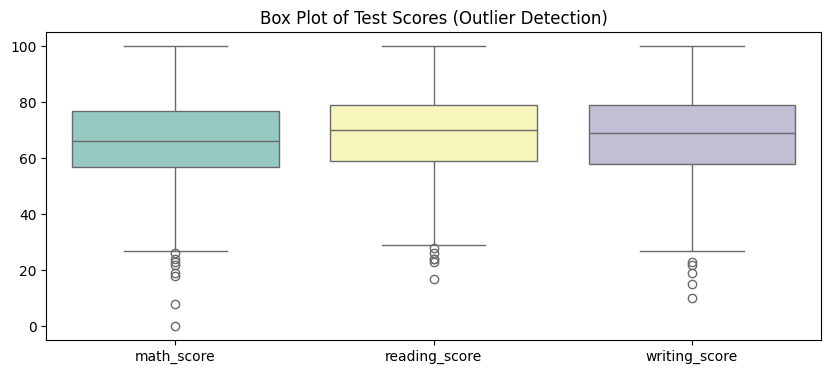

In [35]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[["math_score", "reading_score", "writing_score"]], palette="Set3")
plt.title("Box Plot of Test Scores (Outlier Detection)")
plt.show()